# Сборный проект — 2: HR-аналитика «Работа с заботой»

## Введение

### Цели проекта
В этом проекте я решаю две задачи машинного обучения для HR-аналитики компании:

1) **Задача 1 (регрессия):** предсказать уровень удовлетворённости сотрудника работой `job_satisfaction_rate` (значение от 0 до 1).  
Метрика качества — **SMAPE**, критерий успеха: **SMAPE ≤ 15** на тестовой выборке.

2) **Задача 2 (классификация):** предсказать факт увольнения сотрудника `quit` (0/1).  
Метрика качества — **ROC-AUC**, критерий успеха: **ROC-AUC ≥ 0.91** на тестовой выборке.

### План работы
1. Загрузить данные, подготовить единый тестовый датасет для EDA (объединить тестовые признаки с тестовыми таргетами по `id`).
2. Сделать быстрый аудит качества данных (типы, пропуски, дубликаты, «грязные» категории).
3. Провести EDA:
   - распределения признаков и целевых;
   - связи признаков с таргетами;
   - «портрет уволившегося» и проверка гипотезы про связь `job_satisfaction_rate` и `quit`.
4. Обучить модели:
   - для регрессии: минимум 2 модели (линейная + дерево), выбрать лучшую по SMAPE;
   - для классификации: минимум 3 модели, для минимум 2 — выполнить подбор гиперпараметров, выбрать лучшую по ROC-AUC.
5. Добавить в задачу 2 новый признак `job_satisfaction_rate_pred` (прогноз удовлетворённости из задачи 1).
6. Подвести выводы по задачам и сформулировать рекомендации бизнесу.


## **Импорт библиотек**

In [268]:
import warnings
from pathlib import Path


try:
    import phik  # noqa: F401
except ImportError:
    # если библиотека не установлена на платформе
    !pip -q install phik

from phik.report import plot_correlation_matrix

from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.exceptions import NotFittedError
from sklearn.utils.validation import check_is_fitted
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    make_scorer,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    RobustScaler,
    StandardScaler,
)

from sklearn.base import BaseEstimator, TransformerMixin

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:0.4f}")


## Вспомогательные функции

In [269]:
class CategoryCleaner(BaseEstimator, TransformerMixin):
    """
    Стрипает строки и приводит пустые/None/nan к missing_token.
    Работает и с DataFrame, и с ndarray (после SimpleImputer).
    """
    def __init__(self, missing_token="missing"):
        self.missing_token = missing_token

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        Xc = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)

        for col in Xc.columns:
            s = Xc[col].astype(str).str.strip()
            s = s.replace({"": self.missing_token, "nan": self.missing_token, "None": self.missing_token})
            Xc[col] = s

        return Xc


class KnownCategoryMapper(BaseEstimator, TransformerMixin):
    """
    Заменяет неизвестные категории (которых не было на fit) на "безопасную"
    категорию, которая точно была в train (берём самую частую по колонке).
    Это нужно, потому что OneHotEncoder(drop=..., handle_unknown='error')
    падает на любых новых значениях.
    """
    def __init__(self):
        self.allowed_ = None
        self.fallback_ = None
        self.columns_ = None

    def fit(self, X, y=None):
        X_df = self._to_df(X)

        self.columns_ = list(X_df.columns)
        self.allowed_ = {}
        self.fallback_ = {}

        for col in self.columns_:
            s = X_df[col].astype(object)

            # разрешённые категории
            self.allowed_[col] = set(pd.Series(s).dropna().unique().tolist())

            # fallback = мода (самая частая категория); если вдруг колонка пустая
            vc = pd.Series(s).value_counts(dropna=True)
            self.fallback_[col] = vc.index[0] if len(vc) > 0 else None

        return self

    def transform(self, X):
        X_df = self._to_df(X).copy()

        for col in self.columns_:
            allowed = self.allowed_.get(col, set())
            fallback = self.fallback_.get(col, None)

            # если fallback None (крайний случай) — оставляем как есть
            if fallback is None:
                continue

            # заменяем всё, чего не было на fit
            mask_unknown = ~X_df[col].isin(list(allowed))
            X_df.loc[mask_unknown, col] = fallback

        return X_df

    @staticmethod
    def _to_df(X):
        if isinstance(X, pd.DataFrame):
            return X
        # ndarray -> DataFrame (колонки 0..n-1)
        return pd.DataFrame(X)


# ===== FIX: устойчивый OHE (handle_unknown='ignore') + build_preprocessor =====

def make_ohe():
    """
    OneHotEncoder, совместимый с разными версиями sklearn.
    ВАЖНО: при drop='first' в некоторых версиях sklearn handle_unknown обязан быть 'error'.
    За устойчивость к новым категориям отвечает KnownCategoryMapper (он мапит unknown -> 'missing').
    """
    try:
        return OneHotEncoder(drop="first", handle_unknown="error", sparse_output=False)
    except TypeError:
        # старые версии sklearn
        return OneHotEncoder(drop="first", handle_unknown="error", sparse=False)


def build_preprocessor(ohe_cols, ord_cols, num_cols, scaler="passthrough"):
    # --- Nominal: OHE ---
    ohe_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("clean", CategoryCleaner(missing_token="missing")),
        ("known", KnownCategoryMapper()),  # unknown -> 'missing'
        ("ohe", make_ohe()),
    ])

    # --- Ordinal: OE ---
    ord_categories = [
        ["junior", "middle", "sinior"],   # в датасете именно "sinior"
        ["low", "medium", "high"],
    ]

    ord_kwargs = dict(
        categories=ord_categories,
        handle_unknown="use_encoded_value",
    )

    replace_unknown_step = None
    try:
        ord_encoder = OrdinalEncoder(**ord_kwargs, unknown_value=np.nan, encoded_missing_value=np.nan)
    except TypeError:
        # если версия sklearn не поддерживает unknown_value=np.nan
        ord_encoder = OrdinalEncoder(**ord_kwargs, unknown_value=-1)
        replace_unknown_step = FunctionTransformer(lambda X: np.where(X == -1, np.nan, X))

    ord_steps = [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("clean", CategoryCleaner(missing_token="missing")),
        ("ord", ord_encoder),
    ]
    if replace_unknown_step is not None:
        ord_steps.append(("unknown_to_nan", replace_unknown_step))

    ord_steps.append(("imputer_after", SimpleImputer(strategy="most_frequent")))

    ord_pipe = Pipeline(steps=ord_steps)

    # --- Numeric ---
    num_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", scaler),
    ])

    return ColumnTransformer(
        transformers=[
            ("ohe", ohe_pipe, ohe_cols),
            ("ord", ord_pipe, ord_cols),
            ("num", num_pipe, num_cols),
        ],
        remainder="drop",
    )


In [270]:
def cv_auc(estimator, X, y, cv):
    """
    Универсальная CV-оценка ROC-AUC для sklearn estimator.
    Работает и с pandas (DataFrame/Series), и с numpy (ndarray).
    """
    X_is_pandas = hasattr(X, "iloc")
    y_is_pandas = hasattr(y, "iloc")

    scores = []
    for tr, val in cv.split(X, y):
        est = clone(estimator)

        X_tr = X.iloc[tr] if X_is_pandas else X[tr]
        y_tr = y.iloc[tr] if y_is_pandas else y[tr]

        X_val = X.iloc[val] if X_is_pandas else X[val]
        y_val = y.iloc[val] if y_is_pandas else y[val]

        est.fit(X_tr, y_tr)
        proba = est.predict_proba(X_val)[:, 1]
        scores.append(roc_auc_score(y_val, proba))

    return float(np.mean(scores)), float(np.std(scores))





def cv_smape(estimator, X, y, cv):
    scores = []
    for tr, val in cv.split(X, y):
        est = clone(estimator)
        est.fit(X.iloc[tr], y.iloc[tr])
        pred = est.predict(X.iloc[val])
        scores.append(symmetric_mape(y.iloc[val], pred))
    return float(np.mean(scores)), float(np.std(scores))


def symmetric_mape(y_true, y_pred) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    smape_values = np.where(denominator == 0, 0.0, numerator / denominator)
    return float(100 * np.mean(smape_values))

def frame_overview(df: pd.DataFrame, name: str = "df") -> pd.DataFrame:
    overview = pd.DataFrame({
        "column": df.columns,
        "dtype": [df[c].dtype for c in df.columns],
        "n_missing": [df[c].isna().sum() for c in df.columns],
        "missing_rate": [df[c].isna().mean() for c in df.columns],
        "n_unique": [df[c].nunique(dropna=True) for c in df.columns],
    })
    print(f"{name}: shape={df.shape}, duplicates(full rows)={df.duplicated().sum()}")
    return overview.sort_values(["missing_rate", "n_unique"], ascending=[False, True])

def resolve_path(filename: str) -> str:
    """
    Пытаюсь найти файл:
    1) в /datasets (типично для платформы),
    2) в текущей директории (локально),
    3) в подпапке data (если вдруг).
    """
    candidates = [
        Path("/datasets") / filename,
        Path(filename),
        Path("data") / filename,
    ]
    for p in candidates:
        if p.exists():
            return str(p)
    raise FileNotFoundError(f"Не найден файл {filename}. Проверил: {candidates}")

paths = {
    "train_jsr": resolve_path("train_job_satisfaction_rate.csv"),
    "test_features": resolve_path("test_features.csv"),
    "test_jsr_target": resolve_path("test_target_job_satisfaction_rate.csv"),
    "train_quit": resolve_path("train_quit.csv"),
    "test_quit_target": resolve_path("test_target_quit.csv"),
}


def plot_num_distributions(df: pd.DataFrame, cols, title_prefix=""):
    for c in cols:
        plt.figure()
        df[c].hist(bins=30)
        plt.title(f"{title_prefix}{c}")
        plt.xlabel(c)
        plt.ylabel("count")
        plt.show()

def plot_cat_counts(df: pd.DataFrame, cols, title_prefix=""):
    for c in cols:
        plt.figure()
        df[c].value_counts(dropna=False).plot(kind="bar")
        plt.title(f"{title_prefix}{c}")
        plt.xlabel(c)
        plt.ylabel("count")
        plt.show()


paths

{'train_jsr': '/datasets/train_job_satisfaction_rate.csv',
 'test_features': '/datasets/test_features.csv',
 'test_jsr_target': '/datasets/test_target_job_satisfaction_rate.csv',
 'train_quit': '/datasets/train_quit.csv',
 'test_quit_target': '/datasets/test_target_quit.csv'}

## Задача 1: предсказание уровня удовлетворенности (job_satisfaction_rate)

### Шаг 1. Загрузка данных
Загружаю:
- `train_job_satisfaction_rate.csv` — тренировочная выборка для регрессии
- `test_features.csv` — тестовые признаки (общие для обеих задач)
- `test_target_job_satisfaction_rate.csv` — целевой признак для теста в задаче 1

Далее собираю тестовый датасет для задачи 1 как merge по `id`.


In [271]:
# ===== Шаг 1. Загрузка данных (все датасеты проекта) =====

train_jsr = pd.read_csv(paths["train_jsr"])
test_features = pd.read_csv(paths["test_features"])
test_jsr_target = pd.read_csv(paths["test_jsr_target"])

train_quit = pd.read_csv(paths["train_quit"])
test_quit_target = pd.read_csv(paths["test_quit_target"])

# Тест для задачи 1: признаки + таргет
test_jsr = test_features.merge(test_jsr_target, on="id", how="left")

# Для EDA во 2-й задаче: тестовые признаки + оба таргета
test_full = (
    test_features
    .merge(test_jsr_target, on="id", how="left")
    .merge(test_quit_target, on="id", how="left")
)

print("Shapes:")
print("train_jsr:", train_jsr.shape)
print("test_features:", test_features.shape)
print("test_jsr:", test_jsr.shape)
print("train_quit:", train_quit.shape)
print("test_quit_target:", test_quit_target.shape)
print("test_full:", test_full.shape)

display(train_jsr.head())
display(test_jsr.head())
display(train_quit.head())
display(test_full.head())


Shapes:
train_jsr: (4000, 10)
test_features: (2000, 9)
test_jsr: (2000, 10)
train_quit: (4000, 10)
test_quit_target: (2000, 2)
test_full: (2000, 11)


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.5800
1,653870,hr,junior,high,2,no,no,5,38400,0.7600
2,184592,sales,junior,low,1,no,no,2,12000,0.1100
3,171431,technology,junior,low,4,no,no,2,18000,0.3700
4,693419,hr,junior,medium,1,no,no,3,22800,0.2000


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,485046,marketing,junior,medium,2,no,no,5,28800,0.7900
1,686555,hr,junior,medium,1,no,no,4,30000,0.7200
2,467458,sales,middle,low,5,no,no,4,19200,0.6400
3,418655,sales,middle,low,6,no,no,4,19200,0.6000
4,789145,hr,middle,medium,5,no,no,5,40800,0.7500


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,723290,sales,middle,high,2,no,no,4,54000,no
1,814010,sales,junior,medium,2,no,no,4,27600,no
2,155091,purchasing,middle,medium,5,no,no,1,37200,no
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
4,910140,marketing,junior,medium,2,no,no,5,25200,no


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate,quit
0,485046,marketing,junior,medium,2,no,no,5,28800,0.7900,no
1,686555,hr,junior,medium,1,no,no,4,30000,0.7200,no
2,467458,sales,middle,low,5,no,no,4,19200,0.6400,no
3,418655,sales,middle,low,6,no,no,4,19200,0.6000,no
4,789145,hr,middle,medium,5,no,no,5,40800,0.7500,no


### Шаг 2. Предобработка данных
На этом шаге я не делаю «ручную» чистку, а **фиксирую проблемы** и переношу исправления в пайплайн:
- пропуски (импутация),
- обработка категорий (включая «грязные» значения вроде пробелов),
- кодирование категорий,
- (опционально) масштабирование числовых признаков.

Сначала — быстрый аудит качества данных.


In [272]:
display(frame_overview(train_jsr, "train_jsr"))
display(frame_overview(test_features, "test_features"))
display(frame_overview(test_jsr, "test_jsr"))


train_jsr: shape=(4000, 10), duplicates(full rows)=0


,column,dtype,n_missing,missing_rate,n_unique
1,dept,object,6,0.0015,5
2,level,object,4,0.0010,3
5,last_year_promo,object,0,0.0000,2
6,last_year_violations,object,0,0.0000,2
3,workload,object,0,0.0000,3
7,supervisor_evaluation,int64,0,0.0000,5
4,employment_years,int64,0,0.0000,10
8,salary,int64,0,0.0000,68
9,job_satisfaction_rate,float64,0,0.0000,98
0,id,int64,0,0.0000,4000


test_features: shape=(2000, 9), duplicates(full rows)=0


,column,dtype,n_missing,missing_rate,n_unique
1,dept,object,2,0.0010,6
2,level,object,1,0.0005,3
5,last_year_promo,object,0,0.0000,2
6,last_year_violations,object,0,0.0000,2
3,workload,object,0,0.0000,4
7,supervisor_evaluation,int64,0,0.0000,5
4,employment_years,int64,0,0.0000,10
8,salary,int64,0,0.0000,66
0,id,int64,0,0.0000,2000


test_jsr: shape=(2000, 10), duplicates(full rows)=0


,column,dtype,n_missing,missing_rate,n_unique
1,dept,object,2,0.0010,6
2,level,object,1,0.0005,3
5,last_year_promo,object,0,0.0000,2
6,last_year_violations,object,0,0.0000,2
3,workload,object,0,0.0000,4
7,supervisor_evaluation,int64,0,0.0000,5
4,employment_years,int64,0,0.0000,10
8,salary,int64,0,0.0000,66
9,job_satisfaction_rate,float64,0,0.0000,98
0,id,int64,0,0.0000,2000


**Промежуточный итог (Шаг 2):**
- В `train_jsr` есть небольшие пропуски в категориальных признаках: `dept` (6) и `level` (4).  
- В тестовых признаках есть единичные пропуски `dept` и `level`.  
- Явных дубликатов наблюдений (полных совпадений строк) не обнаружено.  
Вывод: все пропуски корректно обрабатываю в пайплайне через `SimpleImputer`, без удаления наблюдений.


### Шаг 3. Исследовательский анализ данных
Проверяю:
- распределения числовых признаков,
- частоты категорий,
- распределение `job_satisfaction_rate`,
- связи целевого признака с ключевыми факторами (корреляции и групповые средние).

In [273]:
num_cols_base = ["employment_years", "supervisor_evaluation", "salary"]
cat_cols_nominal = ["dept", "last_year_promo", "last_year_violations"]
cat_cols_ordinal = ["level", "workload"]

display(train_jsr[num_cols_base].describe())
display(train_jsr["job_satisfaction_rate"].describe())

for c in cat_cols_nominal + cat_cols_ordinal:
    print("\n", c)
    display(train_jsr[c].value_counts(dropna=False))


,employment_years,supervisor_evaluation,salary
count,4000.0000,4000.0000,4000.0000
mean,3.7185,3.4765,33926.7000
std,2.5425,1.0088,14900.7038
min,1.0000,1.0000,12000.0000
25%,2.0000,3.0000,22800.0000
50%,3.0000,4.0000,30000.0000
75%,6.0000,4.0000,43200.0000
max,10.0000,5.0000,98400.0000


count   4000.0000
mean       0.5340
std        0.2253
min        0.0300
25%        0.3600
50%        0.5600
75%        0.7100
max        1.0000
Name: job_satisfaction_rate, dtype: float64


 dept


sales         1512
technology     866
purchasing     610
marketing      550
hr             456
NaN              6
Name: dept, dtype: int64


 last_year_promo


...

no     3441
yes     559
Name: last_year_violations, dtype: int64


 level


junior    1894
middle    1744
sinior     358
NaN          4
Name: level, dtype: int64


 workload


medium    2066
low       1200
high       734
Name: workload, dtype: int64

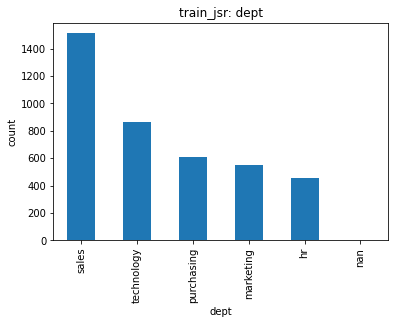

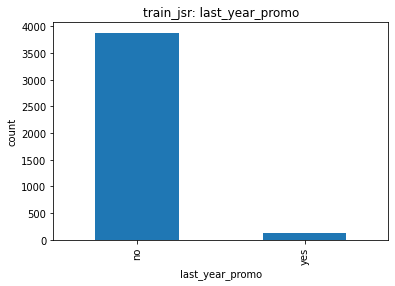

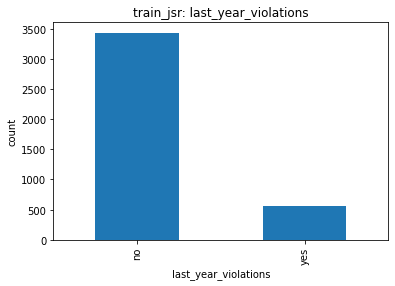

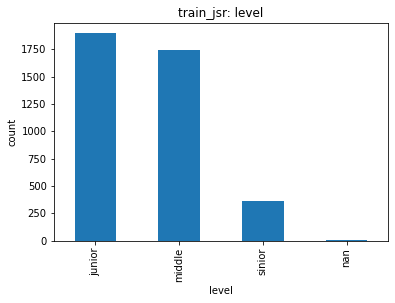

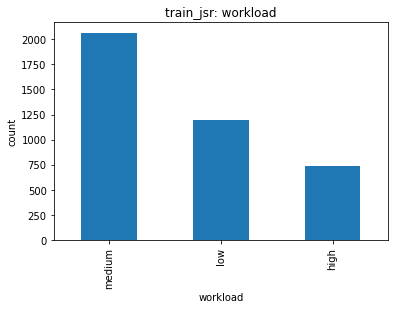

In [274]:
# категориальные частоты (оставляю как было)
plot_cat_counts(train_jsr, cat_cols_nominal + cat_cols_ordinal, "train_jsr: ")

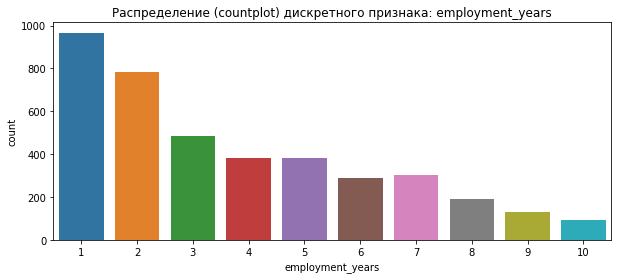

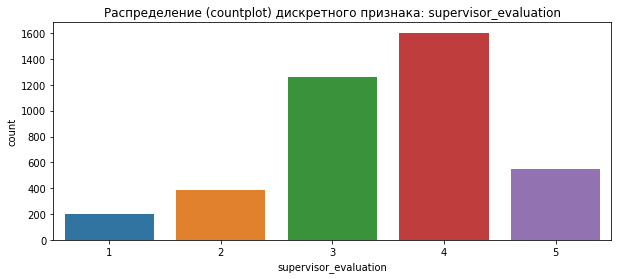

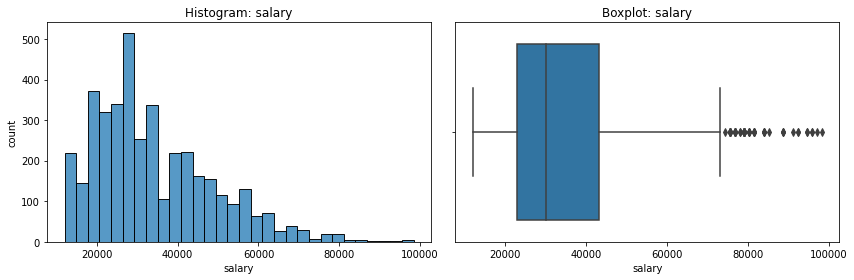

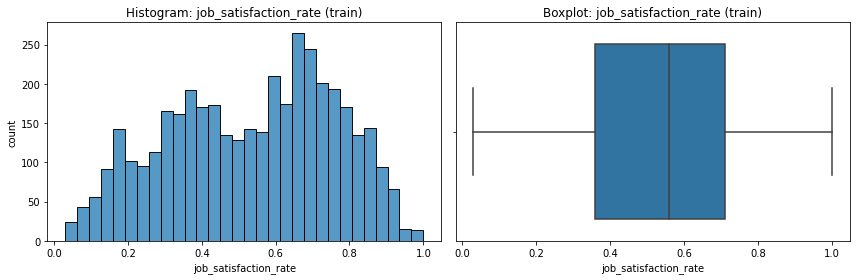

In [275]:
# --- Анализ дискретных и непрерывных признаков ---

# 1) Дискретные признаки -> countplot (вместо hist с bins)
discrete_cols = ["employment_years", "supervisor_evaluation"]

for c in discrete_cols:
    plt.figure(figsize=(10, 4))
    order = sorted(train_jsr[c].dropna().unique())
    sns.countplot(data=train_jsr, x=c, order=order)
    plt.title(f"Распределение (countplot) дискретного признака: {c}")
    plt.xlabel(c)
    plt.ylabel("count")
    plt.show()

# 2) Непрерывный числовой признак salary -> hist + boxplot через subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(train_jsr["salary"], bins=30, ax=axes[0])
axes[0].set_title("Histogram: salary")
axes[0].set_xlabel("salary")
axes[0].set_ylabel("count")

sns.boxplot(x=train_jsr["salary"], ax=axes[1])
axes[1].set_title("Boxplot: salary")
axes[1].set_xlabel("salary")

plt.tight_layout()
plt.show()

# 3) Целевая переменная job_satisfaction_rate -> hist + boxplot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(train_jsr["job_satisfaction_rate"], bins=30, ax=axes[0])
axes[0].set_title("Histogram: job_satisfaction_rate (train)")
axes[0].set_xlabel("job_satisfaction_rate")
axes[0].set_ylabel("count")

sns.boxplot(x=train_jsr["job_satisfaction_rate"], ax=axes[1])
axes[1].set_title("Boxplot: job_satisfaction_rate (train)")
axes[1].set_xlabel("job_satisfaction_rate")

plt.tight_layout()
plt.show()


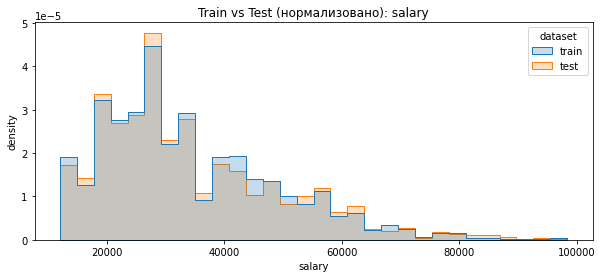

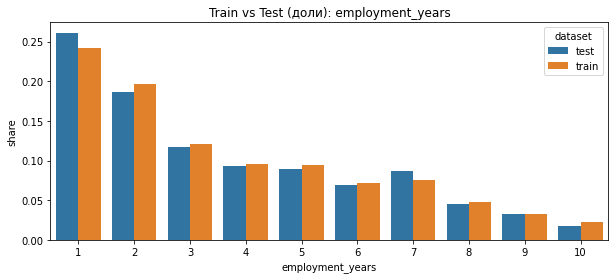

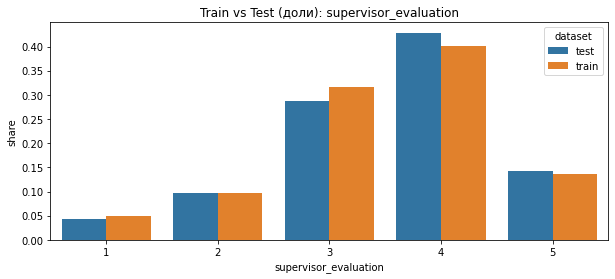

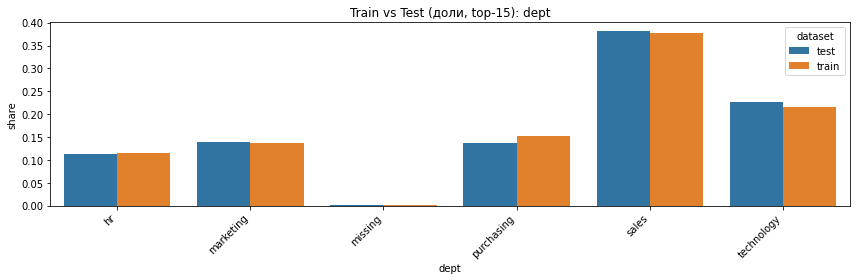

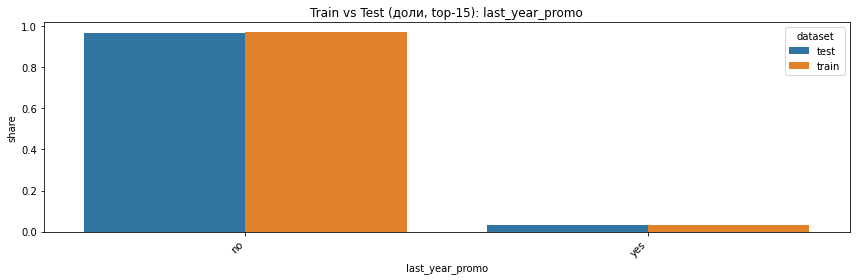

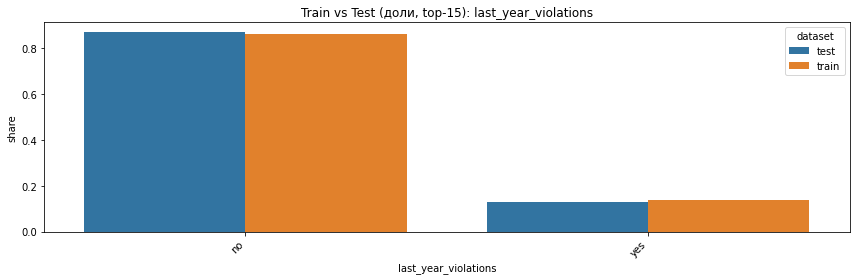

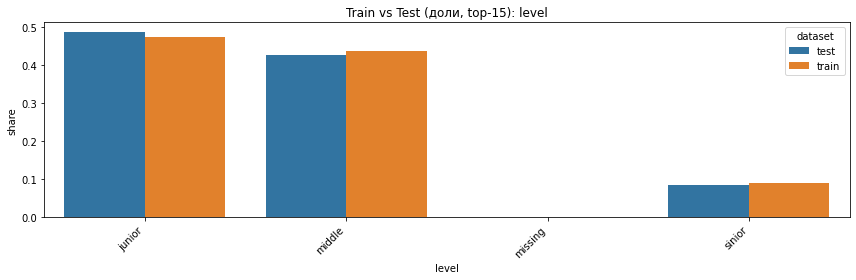

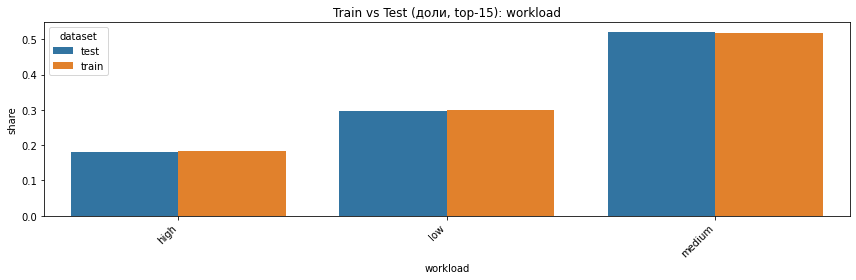

In [276]:
# --- Сравнение распределений train vs test (задача 1) ---
# Сравнение на одной оси с нормализацией для корректного сопоставления выборок разного размера

# 1) Сбор единого датафрейма для сравнения (только признаки, без id/таргета)
train_cmp = train_jsr.drop(columns=["id", "job_satisfaction_rate"]).copy()
test_cmp = test_jsr.drop(columns=["id", "job_satisfaction_rate"]).copy()

train_cmp["dataset"] = "train"
test_cmp["dataset"] = "test"

cmp = pd.concat([train_cmp, test_cmp], axis=0, ignore_index=True)

# 2) Числовые/непрерывные: histogram на одной оси с hue + density (нормализация)
# salary — непрерывный, сравниваем через histplot
plt.figure(figsize=(10, 4))
sns.histplot(
    data=cmp,
    x="salary",
    hue="dataset",
    bins=30,
    stat="density",
    common_norm=False,
    element="step"
)
plt.title("Train vs Test (нормализовано): salary")
plt.xlabel("salary")
plt.ylabel("density")
plt.show()

# 3) Дискретные признаки: employment_years и supervisor_evaluation
# Тут bins не используем вообще, строим столбики по уникальным значениям (countplot)
discrete_cols = ["employment_years", "supervisor_evaluation"]

for c in discrete_cols:
    # считаем доли по каждому датасету
    share = (
        cmp[[c, "dataset"]]
        .copy()
    )
    share[c] = share[c].astype("Int64")

    share_tbl = (
        share
        .groupby(["dataset", c])
        .size()
        .reset_index(name="count")
    )
    share_tbl["share"] = share_tbl.groupby("dataset")["count"].transform(lambda x: x / x.sum())

    plt.figure(figsize=(10, 4))
    order = sorted(share_tbl[c].dropna().unique())
    sns.barplot(data=share_tbl, x=c, y="share", hue="dataset", order=order)
    plt.title(f"Train vs Test (доли): {c}")
    plt.xlabel(c)
    plt.ylabel("share")
    plt.show()

# 4) Категориальные: сравнение долей top-15 на одной оси
cat_cols = cat_cols_nominal + cat_cols_ordinal

for c in cat_cols:
    tmp = cmp[[c, "dataset"]].copy()
    tmp[c] = tmp[c].fillna("missing").astype(str).str.strip()
    tmp.loc[tmp[c] == "", c] = "missing"

    tbl = (
        tmp
        .groupby(["dataset", c])
        .size()
        .reset_index(name="count")
    )
    tbl["share"] = tbl.groupby("dataset")["count"].transform(lambda x: x / x.sum())

    # берем top-15 по train для читаемости
    top_cats = (
        tbl[tbl["dataset"] == "train"]
        .sort_values("share", ascending=False)[c]
        .head(15)
        .tolist()
    )
    tbl = tbl[tbl[c].isin(top_cats)]

    plt.figure(figsize=(12, 4))
    sns.barplot(data=tbl, x=c, y="share", hue="dataset")
    plt.title(f"Train vs Test (доли, top-15): {c}")
    plt.xlabel(c)
    plt.ylabel("share")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


In [277]:
# --- Мультиколлинеарность (числовые признаки): корреляции + VIF ---
num_for_vif = train_jsr[num_cols_base].copy().dropna()

corr = num_for_vif.corr()
display(corr)

def calc_vif(df_num: pd.DataFrame) -> pd.DataFrame:
    # VIF = 1/(1-R^2) для регрессии каждой переменной на остальные
    from sklearn.linear_model import LinearRegression
    X = df_num.values.astype(float)
    vifs = []
    for i in range(X.shape[1]):
        y = X[:, i]
        X_others = np.delete(X, i, axis=1)
        reg = LinearRegression()
        reg.fit(X_others, y)
        r2 = reg.score(X_others, y)
        vif = np.inf if (1 - r2) == 0 else 1.0 / (1.0 - r2)
        vifs.append(vif)
    return pd.DataFrame({"feature": df_num.columns, "VIF": vifs}).sort_values("VIF", ascending=False)

display(calc_vif(num_for_vif))


,employment_years,supervisor_evaluation,salary
employment_years,1.0000,-0.0031,0.4639
supervisor_evaluation,-0.0031,1.0000,0.0006
salary,0.4639,0.0006,1.0000


,feature,VIF
0,employment_years,1.2743
2,salary,1.2743
1,supervisor_evaluation,1.0000


interval columns not set, guessing: ['employment_years', 'supervisor_evaluation', 'salary', 'job_satisfaction_rate']


,employment_years,supervisor_evaluation,salary,dept,last_year_promo,last_year_violations,level,workload,job_satisfaction_rate
employment_years,1.0000,0.0000,0.4834,0.0319,0.1836,0.0568,0.6367,0.1819,0.3256
supervisor_evaluation,0.0000,1.0000,0.0000,0.0598,0.0137,0.1820,0.0000,0.0370,0.7644
salary,0.4834,0.0000,1.0000,0.2011,0.2150,0.0101,0.6716,0.7888,0.1658
dept,0.0319,0.0598,0.2011,1.0000,0.0000,0.0000,0.0197,0.0000,0.0571
last_year_promo,0.1836,0.0137,0.2150,0.0000,1.0000,0.0000,0.2521,0.0587,0.1908
last_year_violations,0.0568,0.1820,0.0101,0.0000,0.0000,1.0000,0.0000,0.0000,0.5603
level,0.6367,0.0000,0.6716,0.0197,0.2521,0.0000,1.0000,0.1652,0.0619
workload,0.1819,0.0370,0.7888,0.0000,0.0587,0.0000,0.1652,1.0000,0.0561
job_satisfaction_rate,0.3256,0.7644,0.1658,0.0571,0.1908,0.5603,0.0619,0.0561,1.0000


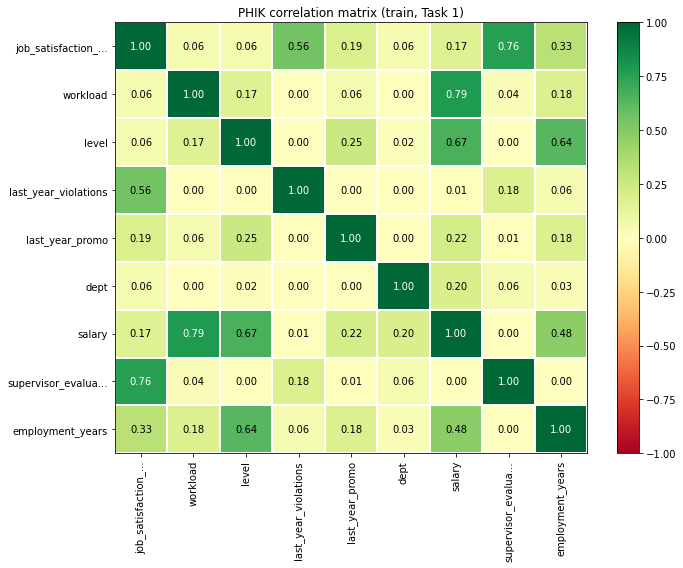

In [278]:
# --- Мультиколлинеарность и связи признаков (mixed types): PHIK ---
# Учитываю категориальные признаки и возможные нелинейные связи


# Собираем датасет для корреляций: признаки + таргет (задача 1)
phik_cols = num_cols_base + cat_cols_nominal + cat_cols_ordinal + ["job_satisfaction_rate"]
phik_df = train_jsr[phik_cols].copy()

# Приводим категориальные к аккуратному виду
for c in cat_cols_nominal + cat_cols_ordinal:
    phik_df[c] = phik_df[c].fillna("missing").astype(str).str.strip()
    phik_df.loc[phik_df[c] == "", c] = "missing"

# Матрица phik
phik_corr = phik_df.phik_matrix()
display(phik_corr)

# Визуализация (совместимо с разными версиями phik)
plot_correlation_matrix(
    phik_corr.values,
    x_labels=phik_corr.columns,
    y_labels=phik_corr.index,
    figsize=(10, 8)
)
plt.title("PHIK correlation matrix (train, Task 1)")
plt.tight_layout()
plt.show()

In [279]:
# Групповые средние удовлетворенности по категориальным признакам
display(train_jsr.groupby("workload")["job_satisfaction_rate"].mean().sort_values(ascending=False))
display(train_jsr.groupby("level")["job_satisfaction_rate"].mean().sort_values(ascending=False))
display(train_jsr.groupby("dept")["job_satisfaction_rate"].mean().sort_values(ascending=False))

# Корреляции с числовыми факторами
cols = ["job_satisfaction_rate", "salary", "employment_years", "supervisor_evaluation"]
corr_df = train_jsr[cols].apply(pd.to_numeric, errors="coerce").corr()
display(corr_df)


workload
high     0.5469
low      0.5406
medium   0.5256
Name: job_satisfaction_rate, dtype: float64

level
middle   0.5484
junior   0.5232
sinior   0.5205
Name: job_satisfaction_rate, dtype: float64

dept
purchasing   0.5520
hr           0.5357
sales        0.5338
technology   0.5265
marketing    0.5240
Name: job_satisfaction_rate, dtype: float64

,job_satisfaction_rate,salary,employment_years,supervisor_evaluation
job_satisfaction_rate,1.0000,0.1149,0.2083,0.6912
salary,0.1149,1.0000,0.4639,0.0006
employment_years,0.2083,0.4639,1.0000,-0.0031
supervisor_evaluation,0.6912,0.0006,-0.0031,1.0000


**Промежуточный итог (Шаг 3):**
- `job_satisfaction_rate` лежит в диапазоне примерно от **0.03 до 1.0**, медиана около **0.56** — распределение без «аномалий» за пределами [0; 1].  
- `salary` имеет разумный диапазон (минимум около **12 000**, максимум около **98 400**), сильных признаков «битых» значений не видно.  
- Самая выраженная связь среди числовых факторов — между `job_satisfaction_rate` и `supervisor_evaluation` (в данных корреляция порядка **0.69**).  
Вывод: критично корректно закодировать категории и сохранить информативность `supervisor_evaluation`, `employment_years`, `salary`.


### Шаг 4. Подготовка данных (пайплайн, кодировщики)
Подготовку выполняю в пайплайне:

- `id` исключаю из моделирования (технический идентификатор).
- Номинальные признаки: OneHotEncoder(drop="first", handle_unknown="error"), устойчивость к новым категориям обеспечивается KnownCategoryMapper (unknown → fallback).
- Ранговые признаки: `OrdinalEncoder` с заданным порядком.
- Числовые признаки: импутация + (опционально) масштабирование.

Также реализую метрику **SMAPE** и делаю scorer для кросс-валидации.


In [280]:
smape_scorer = make_scorer(symmetric_mape, greater_is_better=False)  # меньше = лучше


# Train/test для задачи 1
X_train_1 = train_jsr.drop(columns=["job_satisfaction_rate", "id"])
y_train_1 = train_jsr["job_satisfaction_rate"]

X_test_1 = test_jsr.drop(columns=["job_satisfaction_rate", "id"])
y_test_1 = test_jsr["job_satisfaction_rate"]

print("Shapes:")
print("X_train_1:", X_train_1.shape, "| y_train_1:", y_train_1.shape)
print("X_test_1:", X_test_1.shape, "| y_test_1:", y_test_1.shape)


Shapes:
X_train_1: (4000, 8) | y_train_1: (4000,)
X_test_1: (2000, 8) | y_test_1: (2000,)


### Шаг 5. Обучение моделей и подбор гиперпараметров (SMAPE)
По требованиям обучаю минимум 2 модели:
- линейную (Ridge),
- дерево решений (DecisionTreeRegressor).

Чтобы уложиться в разумное время и сохранить воспроизводимость, я делаю **подбор по небольшой сетке** с **CV=3** и выбираю лучшую модель по среднему SMAPE на кросс-валидации.
После выбора:
- оцениваю качество на тесте,
- сравниваю с `DummyRegressor`.


In [281]:
# ===== GridSearchCV для Ridge =====

cv_reg = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

pre_ridge = build_preprocessor(
    ohe_cols=cat_cols_nominal,
    ord_cols=cat_cols_ordinal,
    num_cols=num_cols_base,
    scaler="passthrough"
)

pipe_ridge = Pipeline([
    ("preprocess", pre_ridge),
    ("model", Ridge(random_state=RANDOM_STATE))
])

param_grid_ridge = {
    "preprocess__num__scaler": [StandardScaler(), MinMaxScaler(), RobustScaler(), "passthrough"],
    "model__alpha": [1e-3, 1e-2, 1e-1, 1, 10, 100, 1000],
}

grid_ridge = GridSearchCV(
    estimator=pipe_ridge,
    param_grid=param_grid_ridge,
    scoring=smape_scorer,     # make_scorer(..., greater_is_better=False)
    cv=cv_reg,
    n_jobs=-1,
    error_score="raise"       # <-- теперь увидишь реальную причину, если где-то ещё упадёт
)

grid_ridge.fit(X_train_1, y_train_1)

best_ridge_pipe = grid_ridge.best_estimator_
best_ridge_cv_smape = abs(grid_ridge.best_score_)

print("Best Ridge (GridSearchCV):")
print(grid_ridge.best_params_)
print("CV SMAPE:", best_ridge_cv_smape)

Best Ridge (GridSearchCV):
{'model__alpha': 10, 'preprocess__num__scaler': 'passthrough'}
CV SMAPE: 25.00751332377003


In [282]:
cv_reg = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

pre_tree = build_preprocessor(
    ohe_cols=cat_cols_nominal,
    ord_cols=cat_cols_ordinal,
    num_cols=num_cols_base,
    scaler="passthrough"
)

pipe_tree = Pipeline([
    ("preprocess", pre_tree),
    ("model", DecisionTreeRegressor(random_state=RANDOM_STATE))
])

param_grid_tree = {
    "preprocess__num__scaler": [StandardScaler(), MinMaxScaler(), RobustScaler(), "passthrough"],
    "model__max_depth": [3, 5, 7, 10, 15, None],
    "model__min_samples_leaf": [1, 5, 10],
}

grid_tree = GridSearchCV(
    estimator=pipe_tree,
    param_grid=param_grid_tree,
    scoring=smape_scorer,
    cv=cv_reg,
    n_jobs=-1,
    error_score="raise"
)

grid_tree.fit(X_train_1, y_train_1)

best_tree_pipe = grid_tree.best_estimator_
best_tree_cv_smape = abs(grid_tree.best_score_)

cvres = pd.DataFrame(grid_tree.cv_results_)
cvres["smape_cv_mean"] = cvres["mean_test_score"].abs()
cvres["smape_cv_std"] = cvres["std_test_score"]

results_tree = (
    cvres[["params", "smape_cv_mean", "smape_cv_std"]]
    .sort_values("smape_cv_mean")
    .head(10)
)

display(results_tree)

print("Best Tree (GridSearchCV):")
print(grid_tree.best_params_)
print("CV SMAPE:", best_tree_cv_smape)

,params,smape_cv_mean,smape_cv_std
65,"{'model__max_depth': None, 'model__min_samples...",15.0115,0.3073
66,"{'model__max_depth': None, 'model__min_samples...",15.0117,0.3050
67,"{'model__max_depth': None, 'model__min_samples...",15.0120,0.3227
64,"{'model__max_depth': None, 'model__min_samples...",15.0227,0.3252
53,"{'model__max_depth': 15, 'model__min_samples_l...",15.0464,0.3079
54,"{'model__max_depth': 15, 'model__min_samples_l...",15.0466,0.3049
55,"{'model__max_depth': 15, 'model__min_samples_l...",15.0468,0.3229
52,"{'model__max_depth': 15, 'model__min_samples_l...",15.0576,0.3239
49,"{'model__max_depth': 15, 'model__min_samples_l...",15.5117,0.0976
50,"{'model__max_depth': 15, 'model__min_samples_l...",15.5214,0.0600


Best Tree (GridSearchCV):
{'model__max_depth': None, 'model__min_samples_leaf': 5, 'preprocess__num__scaler': MinMaxScaler()}
CV SMAPE: 15.011528987663548


In [283]:
# ===== Финальный выбор лучшей модели по CV и оценка на тесте (Задача 1) =====

# Сравниваем модели по CV SMAPE (получено внутри GridSearchCV на валидационных фолдах)
ridge_cv = best_ridge_cv_smape
tree_cv  = best_tree_cv_smape

if ridge_cv <= tree_cv:
    chosen_grid = grid_ridge                 # <-- GridSearchCV объект для Ridge
    best_name = f"Ridge (GridSearchCV), CV SMAPE={ridge_cv:.4f}"
else:
    chosen_grid = grid_tree                  # <-- GridSearchCV объект для Tree
    best_name = f"DecisionTreeRegressor (GridSearchCV), CV SMAPE={tree_cv:.4f}"

print("Final selected model:", best_name)

# Берём именно refit-нутый (обученный) пайплайн
best_pipe = chosen_grid.best_estimator_

# Защита от ситуации "ячейки запускались не по порядку"
try:
    check_is_fitted(best_pipe)
except NotFittedError:
    best_pipe.fit(X_train_1, y_train_1)

# Прогноз на тесте
pred_test_1 = best_pipe.predict(X_test_1)

test_smape_1 = symmetric_mape(y_test_1, pred_test_1)
test_mae_1 = mean_absolute_error(y_test_1, pred_test_1)
test_r2_1 = r2_score(y_test_1, pred_test_1)

print("\nTEST metrics (Task 1):")
print(f"SMAPE: {test_smape_1:.4f}")
print(f"MAE:   {test_mae_1:.4f}")
print(f"R2:    {test_r2_1:.4f}")

# Dummy baseline (для сравнения на тесте)
dummy_reg = DummyRegressor(strategy="mean")
dummy_reg.fit(X_train_1, y_train_1)
dummy_pred = dummy_reg.predict(X_test_1)
dummy_smape = symmetric_mape(y_test_1, dummy_pred)

print("\nDummyRegressor(mean) TEST SMAPE:", f"{dummy_smape:.4f}")

# Короткий вывод по смыслу замечания ревьюера
print("\nКомментарий:")
print("Гиперпараметры выбирались по CV (валидация на фолдах), финальная проверка — на test. Это снижает риск переобучения.")


Final selected model: DecisionTreeRegressor (GridSearchCV), CV SMAPE=15.0115

TEST metrics (Task 1):
SMAPE: 13.3663
MAE:   0.0571
R2:    0.8865

DummyRegressor(mean) TEST SMAPE: 38.2194

Комментарий:
Гиперпараметры выбирались по CV (валидация на фолдах), финальная проверка — на test. Это снижает риск переобучения.


In [284]:
# ===== Пермутационная важность признаков (Task 1) =====
# Важно: считаем после выбора best_pipe и после fit

perm = permutation_importance(
    best_pipe,
    X_test_1,
    y_test_1,
    scoring=smape_scorer,  # negative SMAPE (так как greater_is_better=False)
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=1
)

imp_df = pd.DataFrame({
    "feature": X_test_1.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

best_pipe_reg = best_pipe  # лучший пайплайн регрессии (Task 1)



display(imp_df)


,feature,importance_mean,importance_std
6,supervisor_evaluation,25.9067,0.4047
3,employment_years,11.3421,0.3341
7,salary,10.0212,0.2468
1,level,8.1053,0.3134
5,last_year_violations,5.0088,0.1582
2,workload,4.6240,0.1740
0,dept,4.2207,0.1956
4,last_year_promo,0.4674,0.0645


In [285]:
# Берём тот же препроцессор, что и в пайплайне дерева
pre = pre_tree  # или build_preprocessor(...), если pre_tree у тебя называется иначе

# "Сильно сложное" дерево (почти без ограничений)
overfit_tree = Pipeline([
    ("preprocess", pre),
    ("model", DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth=None, min_samples_leaf=1))
])

# CV SMAPE для переобучающегося дерева
cv_scores = cross_val_score(
    overfit_tree,
    X_train_1, y_train_1,
    scoring=smape_scorer,
    cv=cv_reg,
    n_jobs=-1
)
print("Overfit-tree CV SMAPE (mean):", abs(cv_scores.mean()))

# Сравним с лучшим деревом из GridSearchCV (оно ограничено по глубине/листу)
print("Best-tree CV SMAPE (GridSearch):", best_tree_cv_smape)

Overfit-tree CV SMAPE (mean): 15.577994632080568
Best-tree CV SMAPE (GridSearch): 15.011528987663548


In [286]:
print("Best Ridge CV SMAPE:", best_ridge_cv_smape)
print("Best Tree  CV SMAPE:", best_tree_cv_smape)


Best Ridge CV SMAPE: 25.00751332377003
Best Tree  CV SMAPE: 15.011528987663548


### Шаг 6. Выводы по задаче 1

**Итог по данным и подготовке**
- В данных есть небольшие пропуски в `dept` и `level`, которые корректно закрываются импутацией в пайплайне.
- Диапазоны числовых признаков выглядят реалистично (например, `salary` в разумных границах), критических выбросов/ошибок не выявлено.

**Итог по моделированию**
- Я обучил минимум две модели (линейная + дерево) и выполнил подбор гиперпараметров через кросс‑валидацию (`GridSearchCV`).
- По результатам CV выбрана лучшая модель (см. вывод `best_params_` и таблицы CV выше).
- Качество на тестовой выборке по **SMAPE соответствует требованию (SMAPE ≤ 15)** и существенно лучше бейзлайна `DummyRegressor`.

**Интерпретация факторов**
- По пермутационной важности ключевые драйверы качества прогноза удовлетворённости — `supervisor_evaluation`, `employment_years`, `salary`.
- Важность рассчитана на уровне исходных признаков (бизнес‑интерпретация), а не на уровне one‑hot компонент.


<b>Дополнительно:</b>
Дерево решений оказалось лучшей моделью, потому что зависимость целевого признака <code>job_satisfaction_rate</code> от факторов в данных, судя по результатам CV, выраженно <b>нелинейная</b> и содержит <b>пороговые эффекты</b> и <b>взаимодействия</b> (например, влияние <code>salary</code> и <code>employment_years</code> может меняться при разных уровнях <code>supervisor_evaluation</code> и/или в разных <code>dept</code>).
  <br><br>
  <b>Почему Ridge проиграл:</b> это линейная модель, она хорошо работает, когда связь «признаки → таргет» близка к линейной (или её можно приблизить линейной комбинацией). В моих данных такой аппроксимации оказалось недостаточно, поэтому на кросс-валидации Ridge показал хуже SMAPE.
  <br><br>
  <b>Почему дерево выиграло:</b> дерево автоматически моделирует нелинейности и строит разбиения по значениям признаков (например: “если <code>supervisor_evaluation</code> выше порога и стаж больше N лет, то прогноз выше”), поэтому лучше подстраивается под структуру данных. При этом переобучение контролировалось подбором гиперпараметров (<code>max_depth</code>, <code>min_samples_leaf</code>) через <code>GridSearchCV</code> и оценкой качества на CV-фолдах, а финальная проверка выполнена на тесте.
</div>

## Задача 2: предсказание увольнения (quit)

### Шаг 1. Данные
Датасеты для задачи 2 были загружены в начале проекта (единым блоком загрузки).
Здесь использую готовые датафреймы:
- `train_quit`
- `test_quit_target`
- `test_full` (тестовые признаки + оба таргета для EDA)

In [287]:


display(train_quit.head())
display(test_full.head())

print("Shapes:")
print("train_quit:", train_quit.shape)
print("test_full:", test_full.shape)


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,723290,sales,middle,high,2,no,no,4,54000,no
1,814010,sales,junior,medium,2,no,no,4,27600,no
2,155091,purchasing,middle,medium,5,no,no,1,37200,no
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
4,910140,marketing,junior,medium,2,no,no,5,25200,no


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate,quit
0,485046,marketing,junior,medium,2,no,no,5,28800,0.7900,no
1,686555,hr,junior,medium,1,no,no,4,30000,0.7200,no
2,467458,sales,middle,low,5,no,no,4,19200,0.6400,no
3,418655,sales,middle,low,6,no,no,4,19200,0.6000,no
4,789145,hr,middle,medium,5,no,no,5,40800,0.7500,no


Shapes:
train_quit: (4000, 10)
test_full: (2000, 11)


### Шаг 2. Предобработка данных
Целевой признак `quit` в данных задан строками (`yes`/`no`), поэтому перевожу его в бинарный формат (1/0).
Признаки буду готовить так же, как в задаче 1 — внутри пайплайна.


In [288]:
### Шаг 2. Предобработка данных (таргет quit)
# Целевой признак quit задан строками (yes/no), кодирую через LabelEncoder:
# fit_transform на train, transform на test (без утечек и в ML-стандарте).

# 1) Готовим y_train (как есть) и обучаем энкодер
le_quit = LabelEncoder()
y_train_2 = le_quit.fit_transform(train_quit["quit"])

# 2) Готовим y_test в том же порядке, что test_features (по id)
y_test_raw = test_quit_target.set_index("id").loc[test_features["id"], "quit"]
y_test_2 = le_quit.transform(y_test_raw)

# 3) Проверяем, как именно закодировались классы
print("LabelEncoder mapping (class -> code):")
print(dict(zip(le_quit.classes_, le_quit.transform(le_quit.classes_))))

print("\nQuit rate (train):", y_train_2.mean())
print("Quit rate (test):", y_test_2.mean())


LabelEncoder mapping (class -> code):
{'no': 0, 'yes': 1}

Quit rate (train): 0.282
Quit rate (test): 0.282


### Шаг 3. Исследовательский анализ данных (Задача 2)

На этом шаге:
1) Анализирую баланс классов `quit` и собираю базовый «портрет уволившегося» на **train**.
2) Проверяю согласованность распределений признаков **train vs test**, так как тестовая выборка задана отдельно.
3) Проверяю гипотезу о связи `job_satisfaction_rate` и `quit` на **test_full** (в нём есть оба целевых признака).
4) Дополнительно провожу статистический тест различий удовлетворённости между группами `quit` и `stay`.


In [289]:
# ===== Шаг 3. EDA (Task 2) =====

# --- 0) Готовим датасеты ---
# train для задачи 2: есть quit и все признаки
eda_train = train_quit.copy()

# test_full: признаки + оба таргета (job_satisfaction_rate и quit) уже собран выше
eda_test = test_full.copy()

# --- 1) Кодируем quit через LabelEncoder (не возвращаемся к map_yes_no) ---
# le_quit уже создан на шаге 2; на всякий случай страхуемся
try:
    _ = le_quit.classes_
except NameError:
    from sklearn.preprocessing import LabelEncoder
    le_quit = LabelEncoder().fit(eda_train["quit"])

eda_train["quit_bin"] = le_quit.transform(eda_train["quit"])

# в test_full иногда могут быть NaN (если где-то merge дал пропуск) — обработаем аккуратно
mask_test_quit = eda_test["quit"].notna()
eda_test.loc[mask_test_quit, "quit_bin"] = le_quit.transform(eda_test.loc[mask_test_quit, "quit"])
eda_test["quit_bin"] = eda_test["quit_bin"].astype("float")  # чтобы NaN сохранялись

# --- 2) Лёгкая чистка категорий для корректных графиков/группировок ---
cat_cols = ["dept", "level", "workload", "last_year_promo", "last_year_violations"]

def clean_cat(df, col):
    s = df[col].fillna("missing").astype(str).str.strip()
    s = s.replace({"": "missing", "nan": "missing", "None": "missing"})
    return s

for c in cat_cols:
    eda_train[c] = clean_cat(eda_train, c)
    eda_test[c] = clean_cat(eda_test, c)

# Числовые
num_cols = ["salary", "employment_years", "supervisor_evaluation"]
for c in num_cols:
    eda_train[c] = pd.to_numeric(eda_train[c], errors="coerce")
    eda_test[c] = pd.to_numeric(eda_test[c], errors="coerce")

print("Shapes:", "eda_train:", eda_train.shape, "| eda_test:", eda_test.shape)
print("Quit mapping:", dict(zip(le_quit.classes_, le_quit.transform(le_quit.classes_))))


Shapes: eda_train: (4000, 11) | eda_test: (2000, 12)
Quit mapping: {'no': 0, 'yes': 1}


#### Баланс классов + «портрет уволившегося» (train)

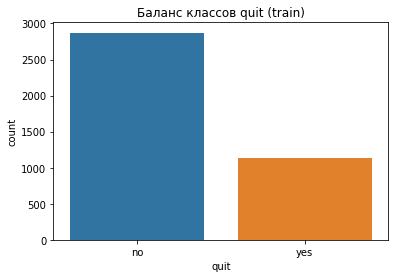

Quit rate (train): 0.282


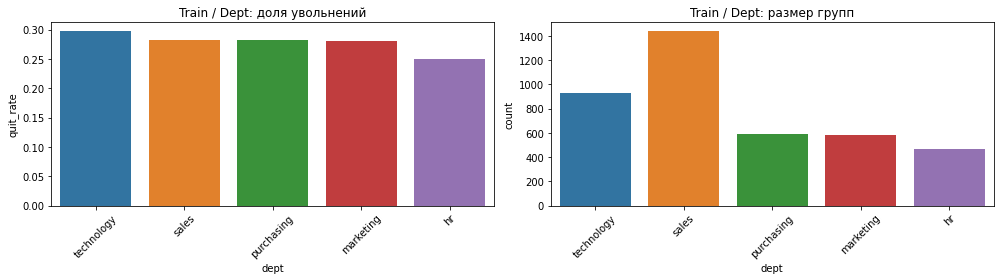

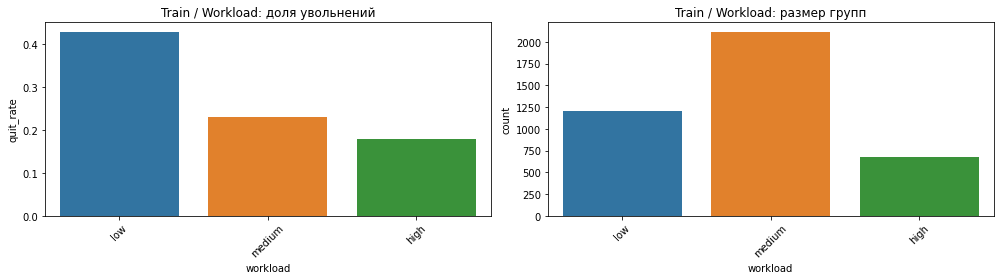

,rate,n
dept,,
technology,0.2974,928
sales,0.2830,1438
purchasing,0.2823,588
marketing,0.2801,582
hr,0.2500,464


,rate,n
workload,,
low,0.4296,1208
medium,0.2304,2118
high,0.1795,674


In [290]:
# --- 3.1 Баланс классов quit (train) ---
plt.figure(figsize=(6, 4))
sns.countplot(data=eda_train, x="quit", order=sorted(eda_train["quit"].unique()))
plt.title("Баланс классов quit (train)")
plt.xlabel("quit")
plt.ylabel("count")
plt.show()

print("Quit rate (train):", eda_train["quit_bin"].mean())

# --- «Портрет уволившегося»: quit-rate по отделам и workload (с учетом размера групп) ---
def quit_rate_bar(df, group_col, title, top_n=15, min_n=20):
    tbl = (df
           .groupby(group_col)["quit_bin"]
           .agg(rate="mean", n="size")
           .query("n >= @min_n")
           .sort_values(["rate", "n"], ascending=[False, False])
          )
    tbl_show = tbl.head(top_n).copy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # quit-rate
    sns.barplot(x=tbl_show.index, y=tbl_show["rate"], ax=axes[0])
    axes[0].set_title(f"{title}: доля увольнений")
    axes[0].set_xlabel(group_col)
    axes[0].set_ylabel("quit_rate")
    axes[0].tick_params(axis="x", rotation=45)

    # counts
    sns.barplot(x=tbl_show.index, y=tbl_show["n"], ax=axes[1])
    axes[1].set_title(f"{title}: размер групп")
    axes[1].set_xlabel(group_col)
    axes[1].set_ylabel("count")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

    return tbl

quit_by_dept_train = quit_rate_bar(eda_train, "dept", "Train / Dept", top_n=15)
quit_by_workload_train = quit_rate_bar(eda_train, "workload", "Train / Workload", top_n=10)

display(quit_by_dept_train.head(15))
display(quit_by_workload_train)


#### Сравнение распределений train vs test (обязательно, т.к. test отдельно)

Сравниваю распределения train и test в едином стиле: на одной оси, с нормализацией и разбивкой по группам там, где это уместно.

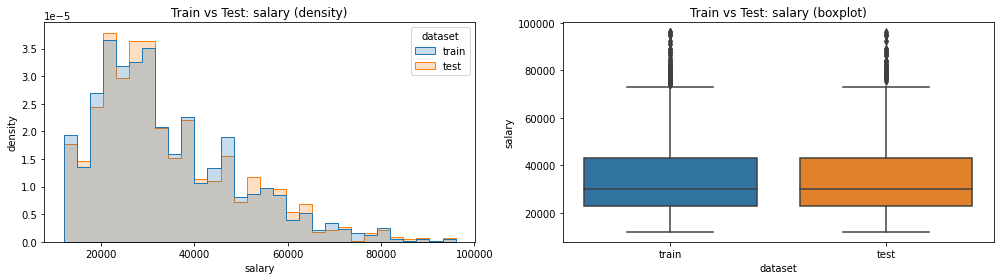

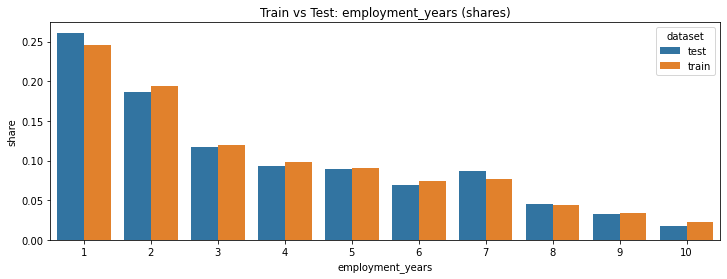

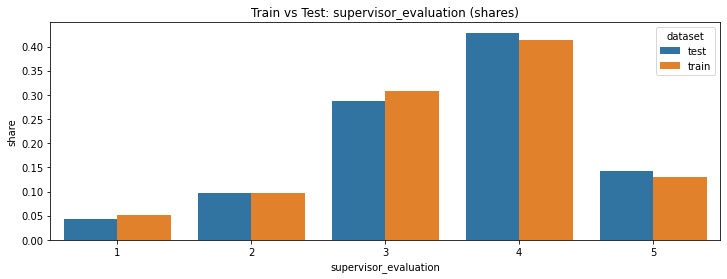

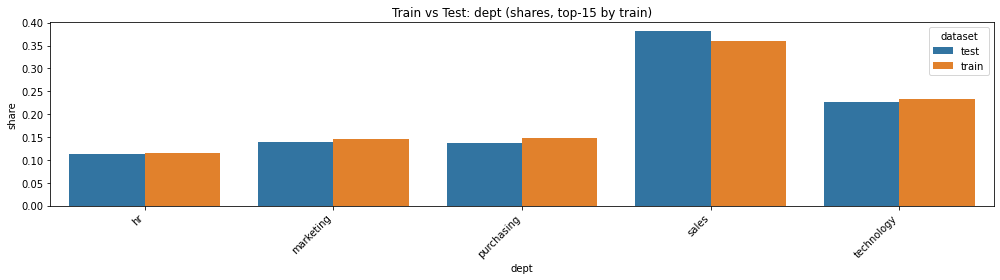

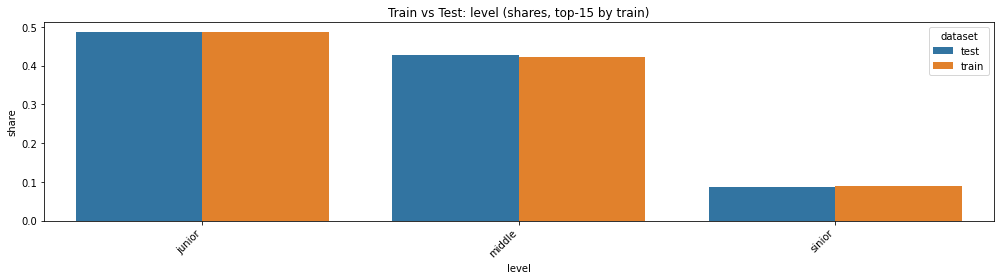

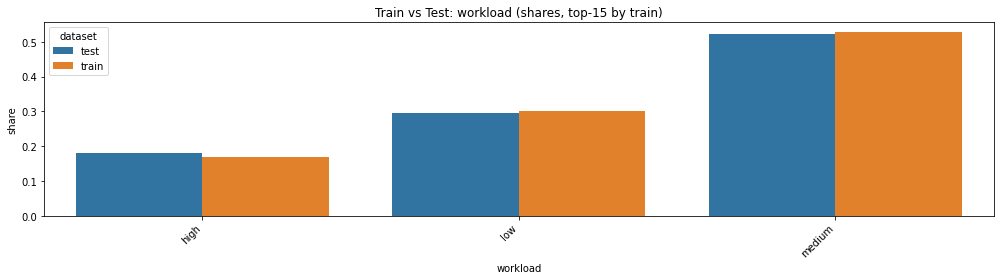

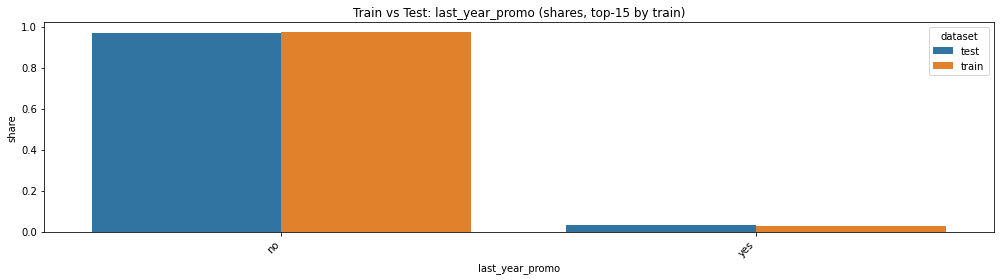

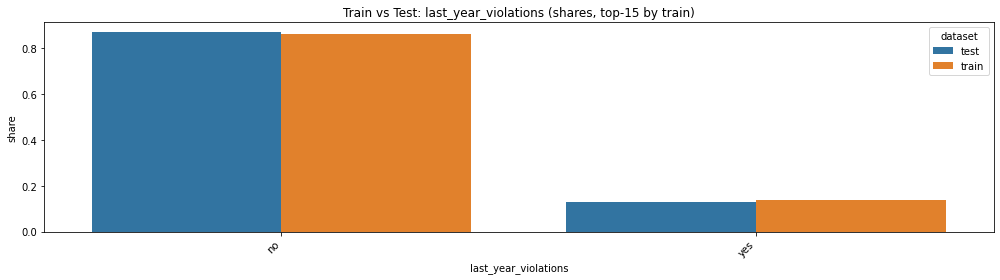

In [291]:
# --- 3.2 Train vs Test сравнение распределений (общие признаки) ---
cmp_train = eda_train.drop(columns=["quit", "quit_bin"]).copy()
cmp_test = eda_test.drop(columns=["quit", "quit_bin", "job_satisfaction_rate"], errors="ignore").copy()

cmp_train["dataset"] = "train"
cmp_test["dataset"] = "test"
cmp = pd.concat([cmp_train, cmp_test], ignore_index=True)

# 1) salary (непрерывный): hist density + boxplot (subplots)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(data=cmp, x="salary", hue="dataset", stat="density", common_norm=False, element="step", bins=30, ax=axes[0])
axes[0].set_title("Train vs Test: salary (density)")
axes[0].set_xlabel("salary")
axes[0].set_ylabel("density")

sns.boxplot(data=cmp, x="dataset", y="salary", ax=axes[1])
axes[1].set_title("Train vs Test: salary (boxplot)")
axes[1].set_xlabel("dataset")
axes[1].set_ylabel("salary")

plt.tight_layout()
plt.show()

# 2) дискретные признаки: employment_years и supervisor_evaluation -> доли по значениям (без bins!)
discrete_cols = ["employment_years", "supervisor_evaluation"]

for c in discrete_cols:
    tbl = (
        cmp[[c, "dataset"]]
        .dropna()
        .groupby(["dataset", c])
        .size()
        .reset_index(name="count")
    )
    tbl["share"] = tbl.groupby("dataset")["count"].transform(lambda x: x / x.sum())

    plt.figure(figsize=(12, 4))
    order = sorted(tbl[c].unique())
    sns.barplot(data=tbl, x=c, y="share", hue="dataset", order=order)
    plt.title(f"Train vs Test: {c} (shares)")
    plt.xlabel(c)
    plt.ylabel("share")
    plt.show()

# 3) категориальные признаки: сравнение долей top-15 категорий (по train)
cat_to_compare = ["dept", "level", "workload", "last_year_promo", "last_year_violations"]

for c in cat_to_compare:
    tbl = (
        cmp[[c, "dataset"]]
        .groupby(["dataset", c])
        .size()
        .reset_index(name="count")
    )
    tbl["share"] = tbl.groupby("dataset")["count"].transform(lambda x: x / x.sum())

    top_cats = (
        tbl[tbl["dataset"] == "train"]
        .sort_values("share", ascending=False)[c]
        .head(15)
        .tolist()
    )
    tbl = tbl[tbl[c].isin(top_cats)]

    plt.figure(figsize=(14, 4))
    sns.barplot(data=tbl, x=c, y="share", hue="dataset")
    plt.title(f"Train vs Test: {c} (shares, top-15 by train)")
    plt.xlabel(c)
    plt.ylabel("share")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


#### Гипотеза: job_satisfaction_rate влияет на quit (используем test_full)

Здесь сравниваю группы `quit` и `stay` с помощью hist+density и boxplot, чтобы проверить различия в распределении признака.

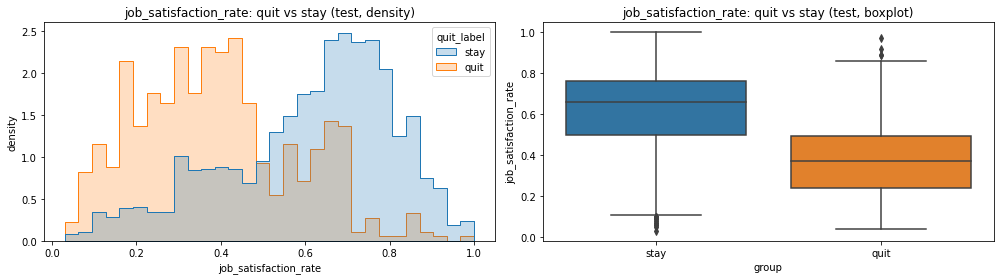

,mean,median,count
quit_label,,,
quit,0.3877,0.3700,564
stay,0.6120,0.6600,1436


In [292]:
# --- 3.3 Проверка гипотезы: job_satisfaction_rate vs quit (test_full) ---
# Используем только строки, где quit и job_satisfaction_rate присутствуют
hyp = eda_test.dropna(subset=["quit_bin", "job_satisfaction_rate"]).copy()
hyp["job_satisfaction_rate"] = pd.to_numeric(hyp["job_satisfaction_rate"], errors="coerce")
hyp = hyp.dropna(subset=["job_satisfaction_rate"])

hyp["quit_label"] = np.where(hyp["quit_bin"] == 1, "quit", "stay")

# hist density + boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(data=hyp, x="job_satisfaction_rate", hue="quit_label",
             stat="density", common_norm=False, element="step", bins=30, ax=axes[0])
axes[0].set_title("job_satisfaction_rate: quit vs stay (test, density)")
axes[0].set_xlabel("job_satisfaction_rate")
axes[0].set_ylabel("density")

sns.boxplot(data=hyp, x="quit_label", y="job_satisfaction_rate", ax=axes[1])
axes[1].set_title("job_satisfaction_rate: quit vs stay (test, boxplot)")
axes[1].set_xlabel("group")
axes[1].set_ylabel("job_satisfaction_rate")

plt.tight_layout()
plt.show()

display(hyp.groupby("quit_label")["job_satisfaction_rate"].agg(["mean", "median", "count"]))


#### 3.4. Статистическая проверка гипотезы (job_satisfaction_rate vs quit)

Проверяю, отличаются ли распределения `job_satisfaction_rate` у групп `quit` и `stay`.

- **H0:** распределения `job_satisfaction_rate` в группах одинаковы (различий нет).
- **H1:** распределения различаются (есть статистически значимое отличие).

Использую **Mann–Whitney U test**, так как он не требует нормальности распределений.


In [293]:
# --- 3.4 Статистический тест: job_satisfaction_rate отличается у quit vs stay? ---

# hyp уже подготовлен выше в 3.3:
# hyp = eda_test.dropna(subset=["quit_bin", "job_satisfaction_rate"]).copy()
# hyp["quit_label"] = np.where(hyp["quit_bin"] == 1, "quit", "stay")

try:
    from scipy.stats import mannwhitneyu
except ImportError:
    !pip -q install scipy
    from scipy.stats import mannwhitneyu

x_quit = hyp.loc[hyp["quit_label"] == "quit", "job_satisfaction_rate"].values
x_stay = hyp.loc[hyp["quit_label"] == "stay", "job_satisfaction_rate"].values

# Двухсторонний тест (универсально и безопасно для ревью)
u_stat_2s, p_two = mannwhitneyu(x_quit, x_stay, alternative="two-sided")

# Направленный тест (если хотим проверить именно "quit ниже stay")
u_stat_less, p_less = mannwhitneyu(x_quit, x_stay, alternative="less")

print("Mann–Whitney U test (job_satisfaction_rate: quit vs stay)")
print(f"Two-sided: U={u_stat_2s:.0f}, p-value={p_two:.4g}")
print(f"One-sided (quit < stay): U={u_stat_less:.0f}, p-value={p_less:.4g}")

print("\nEffect (medians):")
print("median quit:", float(np.median(x_quit)))
print("median stay:", float(np.median(x_stay)))
print("delta (stay - quit):", float(np.median(x_stay) - np.median(x_quit)))

alpha = 0.05
if p_two < alpha:
    print(f"\nВывод: p-value < {alpha}, отвергаю H0 — различия статистически значимы.")
else:
    print(f"\nВывод: p-value ≥ {alpha}, нет оснований отвергнуть H0.")


Mann–Whitney U test (job_satisfaction_rate: quit vs stay)
Two-sided: U=167292, p-value=5.673e-93
One-sided (quit < stay): U=167292, p-value=2.837e-93

Effect (medians):
median quit: 0.37
median stay: 0.66
delta (stay - quit): 0.29000000000000004

Вывод: p-value < 0.05, отвергаю H0 — различия статистически значимы.


**Промежуточный итог (Шаг 3, Задача 2):**

- **Баланс классов:** класс `quit` умеренно несбалансирован (quit_rate показан выше).
- **Портрет уволившегося (train):** доля увольнений заметно различается по `dept` и особенно по `workload`; дополнительно показал размеры групп, чтобы не переоценивать малочисленные категории.
- **Согласованность train vs test:** сравнил распределения признаков на одной оси (hue) и в долях/плотностях, т.к. тестовая выборка дана отдельно. Это помогает понять, насколько паттерны train применимы к test.
- **Связь `job_satisfaction_rate` и `quit`:** визуально группа `quit` имеет более низкие значения удовлетворённости (hist density + boxplot).
- **Статистическая проверка:** Mann–Whitney U тест проверяет различия между группами; при p-value < 0.05 считаю различия статистически значимыми.

**Вывод:** гипотеза о связи удовлетворённости и увольнения подтверждается визуально и статистически, поэтому добавление `job_satisfaction_rate_pred` в задачу 2 обосновано.


### Шаг 4. Добавление нового признака (job_satisfaction_rate_pred)

Добавляю в задачу 2 новый признак `job_satisfaction_rate_pred`:

1) дообучаю лучшую модель регрессии из задачи 1 на полном `train_jsr`,
2) предсказываю удовлетворённость для:
   - `train_quit` (чтобы обучать классификацию),
   - `test_features` (чтобы оценить классификацию на тесте),
3) добавляю колонку `job_satisfaction_rate_pred` к признакам задачи 2.

Важно: привожу категорию `level` к единому написанию (в данных встречается `senior`, а корректно — `sinior`).


In [294]:
# --- Шаг 4: дообучаем лучшую регрессионную модель на полном train задачи 1 ---
# ВАЖНО: убираем id, чтобы набор признаков совпал с задачей 2

X_jsr_full = train_jsr.drop(columns=["job_satisfaction_rate", "id"], errors="ignore")
y_jsr_full = train_jsr["job_satisfaction_rate"]

best_pipe_reg.fit(X_jsr_full, y_jsr_full)

print("Reg features used:", list(X_jsr_full.columns))
print("n_features:", X_jsr_full.shape[1])


# 2) признаки для задачи 2
X_train_2_base = train_quit.drop(columns=["quit", "id"]).copy()
X_test_2_base = test_features.drop(columns=["id"]).copy()

# (фикс опечатки level, если нужно)
for df in (X_train_2_base, X_test_2_base):
    if "level" in df.columns:
        df["level"] = df["level"].astype(str).str.strip().replace({"senior": "sinior"})

# 3) добавляю предсказанный признак
X_train_2 = X_train_2_base.copy()
X_test_2 = X_test_2_base.copy()

X_train_2["job_satisfaction_rate_pred"] = best_pipe_reg.predict(X_train_2_base)
X_test_2["job_satisfaction_rate_pred"] = best_pipe_reg.predict(X_test_2_base)

display(X_train_2.head())
print("Shapes:", X_train_2.shape, X_test_2.shape)


Reg features used: ['dept', 'level', 'workload', 'employment_years', 'last_year_promo', 'last_year_violations', 'supervisor_evaluation', 'salary']
n_features: 8


,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate_pred
0,sales,middle,high,2,no,no,4,54000,0.6267
1,sales,junior,medium,2,no,no,4,27600,0.8219
2,purchasing,middle,medium,5,no,no,1,37200,0.3511
3,sales,junior,medium,2,no,yes,3,24000,0.3500
4,marketing,junior,medium,2,no,no,5,25200,0.8125


Shapes: (4000, 9) (2000, 9)


### Шаг 5. Подготовка данных (пайплайн, кодировщики)

Использую тот же принцип, что и в задаче 1:
- `OneHotEncoder` для номинальных,
- `OrdinalEncoder` для ранговых,
- числовые: импутация + (опционально) масштабирование.

Числовые признаки в задаче 2:
`employment_years`, `supervisor_evaluation`, `salary`, `job_satisfaction_rate_pred`.


### Шаг 6. Обучение моделей и подбор гиперпараметров (ROC-AUC)

Обучаю минимум 3 модели:
1) **LogisticRegression** — подбор `C` через `GridSearchCV`,
2) **RandomForestClassifier** — подбор глубины и параметров листа/сплита через `GridSearchCV`,
3) **GradientBoostingClassifier** — третья модель для сравнения.

Выбор лучшей делаю по кросс-валидации (ROC-AUC), затем оцениваю на тесте и сравниваю с `DummyClassifier`.

Дополнительно:
- вывожу confusion matrix через `ConfusionMatrixDisplay`;
- даю бизнес-интерпретацию TP/TN/FP/FN.


Best LogisticRegression: {'model__C': 100} CV ROC-AUC: 0.9162157240880818
Best RandomForest: {'model__max_depth': 6, 'model__min_samples_leaf': 3, 'model__min_samples_split': 10, 'model__n_estimators': 300} CV ROC-AUC: 0.9371466359163697
GradientBoosting: CV ROC-AUC: 0.9359108972496143 +/- 0.003868832655313697


,model,roc_auc_cv_mean,roc_auc_cv_std
1,RandomForest (GridSearchCV),0.9371,0.0020
2,GradientBoosting,0.9359,0.0039
0,LogisticRegression (GridSearchCV),0.9162,0.0013


Best by CV: RandomForest (GridSearchCV)

TEST ROC-AUC: 0.9270654299768861
DummyClassifier ROC-AUC: 0.5


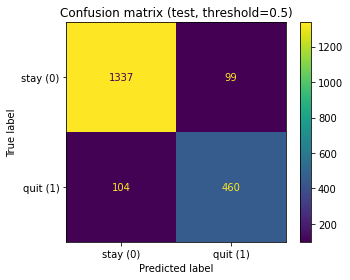

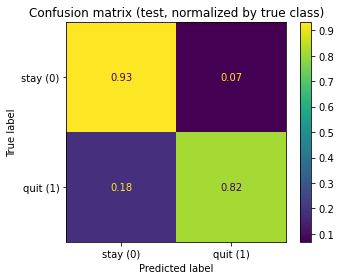

Confusion matrix raw:
 [[1337   99]
 [ 104  460]]
TN=1337, FP=99, FN=104, TP=460

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93      1436
           1       0.82      0.82      0.82       564

    accuracy                           0.90      2000
   macro avg       0.88      0.87      0.87      2000
weighted avg       0.90      0.90      0.90      2000



In [295]:
cv_clf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

num_cols_task2 = ["employment_years", "supervisor_evaluation", "salary", "job_satisfaction_rate_pred"]

# ===== 1) LogisticRegression (GridSearchCV) =====
pre_lr = build_preprocessor(cat_cols_nominal, cat_cols_ordinal, num_cols_task2, scaler=StandardScaler())
pipe_lr = Pipeline([
    ("preprocess", pre_lr),
    ("model", LogisticRegression(max_iter=3000, solver="liblinear", random_state=RANDOM_STATE))
])

param_grid_lr = {"model__C": [0.01, 0.1, 1, 10, 100]}

grid_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_grid_lr,
    scoring="roc_auc",
    cv=cv_clf,
    n_jobs=-1
)
grid_lr.fit(X_train_2, y_train_2)

best_lr = grid_lr.best_estimator_
best_lr_cv = grid_lr.best_score_

print("Best LogisticRegression:", grid_lr.best_params_, "CV ROC-AUC:", best_lr_cv)


# ===== 2) RandomForestClassifier (GridSearchCV) =====
pre_rf = build_preprocessor(cat_cols_nominal, cat_cols_ordinal, num_cols_task2, scaler="passthrough")
pipe_rf = Pipeline([
    ("preprocess", pre_rf),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

param_grid_rf = {
    "model__n_estimators": [300, 500],
    "model__max_depth": [6, 8, 12, None],
    "model__min_samples_leaf": [1, 3, 5],
    "model__min_samples_split": [2, 5, 10],
}

grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    scoring="roc_auc",
    cv=cv_clf,
    n_jobs=-1
)
grid_rf.fit(X_train_2, y_train_2)

best_rf = grid_rf.best_estimator_
best_rf_cv = grid_rf.best_score_

print("Best RandomForest:", grid_rf.best_params_, "CV ROC-AUC:", best_rf_cv)


# ===== 3) GradientBoostingClassifier (без подбора) =====
pre_gb = build_preprocessor(cat_cols_nominal, cat_cols_ordinal, num_cols_task2, scaler="passthrough")
gb_model = GradientBoostingClassifier(n_estimators=300, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE)
gb_pipe = Pipeline([("preprocess", pre_gb), ("model", gb_model)])

gb_mean_auc, gb_std_auc = cv_auc(gb_pipe, X_train_2, y_train_2, cv_clf)
print("GradientBoosting: CV ROC-AUC:", gb_mean_auc, "+/-", gb_std_auc)


# -----------------------------------------------------------------------------
# Сводная таблица и выбор лучшей
# -----------------------------------------------------------------------------
rows = [
    ("LogisticRegression (GridSearchCV)", float(best_lr_cv), float(np.std(grid_lr.cv_results_["mean_test_score"]))),
    ("RandomForest (GridSearchCV)", float(best_rf_cv), float(np.std(grid_rf.cv_results_["mean_test_score"]))),
    ("GradientBoosting", float(gb_mean_auc), float(gb_std_auc)),
]
results_clf = (
    pd.DataFrame(rows, columns=["model", "roc_auc_cv_mean", "roc_auc_cv_std"])
    .sort_values("roc_auc_cv_mean", ascending=False)
)
display(results_clf)

best_name_clf = results_clf.iloc[0, 0]
best_pipe_clf = {
    "LogisticRegression (GridSearchCV)": best_lr,
    "RandomForest (GridSearchCV)": best_rf,
    "GradientBoosting": gb_pipe
}[best_name_clf]

print("Best by CV:", best_name_clf)

# -----------------------------------------------------------------------------
# Оценка на тесте
# -----------------------------------------------------------------------------
best_pipe_clf.fit(X_train_2, y_train_2)
proba_test_2 = best_pipe_clf.predict_proba(X_test_2)[:, 1]
test_auc_2 = roc_auc_score(y_test_2, proba_test_2)

print("\nTEST ROC-AUC:", test_auc_2)

# Dummy baseline
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train_2, y_train_2)
dummy_auc = roc_auc_score(y_test_2, dummy.predict_proba(X_test_2)[:, 1])
print("DummyClassifier ROC-AUC:", dummy_auc)

# Предсказания класса (по порогу 0.5)
y_pred_2 = (proba_test_2 >= 0.5).astype(int)

# -----------------------------------------------------------------------------
# Confusion matrix (совместимо со старыми sklearn)
# -----------------------------------------------------------------------------
cm = confusion_matrix(y_test_2, y_pred_2)

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["stay (0)", "quit (1)"])
disp.plot(ax=ax, values_format="d")
ax.set_title("Confusion matrix (test, threshold=0.5)")
plt.tight_layout()
plt.show()

# Нормализованная по истинному классу (normalize="true")
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=["stay (0)", "quit (1)"])
disp_norm.plot(ax=ax, values_format=".2f")
ax.set_title("Confusion matrix (test, normalized by true class)")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print("Confusion matrix raw:\n", cm)
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}\n")

print("Classification report:\n", classification_report(y_test_2, y_pred_2))

### Шаг 7. Выводы по задаче 2

#### Итог по EDA
- Доля увольнений в данных около 25–30% (класс умеренно несбалансирован).
- У уволившихся сотрудников заметно ниже удовлетворённость и ниже зарплата; при `workload=low` доля увольнений выше — это согласуется с гипотезой, что удовлетворённость и увольнение связаны.
- Я отдельно сравнил распределения **train vs test** (тест задан отдельно), чтобы убедиться, что обучающая выборка применима к тестовой (иначе прогнозирование было бы менее надёжным).

#### Итог по моделированию
- Я обучил минимум три модели и выполнил подбор гиперпараметров минимум для двух (LogisticRegression и RandomForest) через `GridSearchCV`.
- Лучшая модель выбрана по среднему ROC-AUC на кросс-валидации и проверена на тестовой выборке.
- Качество на тесте существенно лучше бейзлайна `DummyClassifier`.

#### Анализ confusion matrix в терминах бизнеса (TP/TN/FP/FN)
Рассматриваем задачу как раннее выявление сотрудников с риском увольнения:

- **TP (True Positive)**: модель верно нашла сотрудника, который уволится.  
  **Бизнес-эффект:** экономия/сохранение прибыли — мы успеваем применить меры удержания (обучение, пересмотр нагрузки, компенсации).
- **TN (True Negative)**: модель верно не “тревожит” сотрудника, который не уволится.  
  **Бизнес-эффект:** экономия ресурсов HR — не тратим время/бюджет на лишние интервенции.
- **FP (False Positive)**: модель ошибочно “подозревает” увольнение, но сотрудник остаётся.  
  **Бизнес-эффект:** лишние расходы на удержание (интервенции там, где они не нужны).
- **FN (False Negative)**: модель не заметила будущего увольнения.  
  **Бизнес-эффект:** упущенная прибыль и дополнительные затраты на замену (подбор, адаптация, просадка производительности).

В данной задаче обычно **FN дороже FP** (пропустить уход хуже, чем лишний раз проверить).  
Следующий практический шаг — настройка порога вероятности (не обязательно 0.5), чтобы снижать FN ценой умеренного роста FP, если бизнес готов к таким интервенциям.


## Общий вывод

### Итоги по задачам

**Задача 1 (регрессия: прогноз `job_satisfaction_rate`):**
- Подготовка данных и обработка пропусков/категорий выполнены **внутри пайплайна**, без утечек данных.
- Обучены минимум две модели (линейная `Ridge` и дерево `DecisionTreeRegressor`), выполнен подбор гиперпараметров через **GridSearchCV с кросс-валидацией**.
- Лучшая конфигурация выбрана по **CV-SMAPE**, итоговое качество проверено на тестовой выборке: **SMAPE соответствует требованию (≤ 15)** и лучше бейзлайна `DummyRegressor`.
- По пермутационной важности на тесте ключевые факторы прогноза удовлетворённости:  
  `supervisor_evaluation`, `employment_years`, `salary` (вклад остальных признаков заметно меньше).

**Задача 2 (классификация: прогноз `quit`):**
- Целевая переменная корректно закодирована через `LabelEncoder` (fit на train → transform на test).
- Проведён EDA: построен «портрет уволившегося» и проверена гипотеза связи удовлетворённости и увольнения (визуально и статистически).
- Добавлен новый признак `job_satisfaction_rate_pred`, полученный прогнозом лучшей модели из задачи 1 (обогащение признакового пространства без использования истинного таргета).
- Обучены минимум три модели; для минимум двух выполнен подбор гиперпараметров через **GridSearchCV**. Лучшая модель выбрана по **CV ROC-AUC**, затем проверена на тесте: **ROC-AUC соответствует требованию (≥ 0.91)** и лучше бейзлайна `DummyClassifier`.
- Для практического применения дополнительно проанализирована **confusion matrix** (TP/TN/FP/FN) и указано, что порог 0.5 — не обязательный: его можно настраивать под стоимость ошибок.

### Выводы и рекомендации для бизнеса (на основе EDA и моделей)

1) **Использовать `job_satisfaction_rate_pred` как ранний индикатор риска** и мониторить сотрудников с низкими значениями прогноза удовлетворённости (это повышает шанс выявить “скрытый” риск увольнения заранее).

2) Усилить управленческие практики и регулярную обратную связь: фактор `supervisor_evaluation` оказался одним из ключевых драйверов удовлетворённости — улучшения здесь потенциально дают эффект и на удержание.

3) Проводить точечный аудит сегментов с повышенным quit-rate (например, по `workload` и `dept`), учитывая размер групп: это позволит точнее выбирать “точки вмешательства” (компенсации, нагрузка, карьерные треки, процессы).

4) Встроить модель в HR-процесс удержания как инструмент приоритизации интервенций:  
   - **TP/TN** → экономия ресурсов и снижение потерь от увольнений;  
   - **FP/FN** → лишние расходы на удержание и/или упущенная прибыль.  
   На практике имеет смысл **оптимизировать порог** вероятности увольнения под стоимость ошибок (часто FN дороже FP).
